Environment

```shell

conda create -n refgra python=3.10

conda activate refgra

conda install pandas networkx matplotlib pyvis ipykernel requests tqdm nbconvert -y
```

## Libraries

In [18]:
import requests
import pandas as pd
from tqdm import tqdm
import networkx as nx

from matplotlib import pyplot as plt
from time import time

from pyvis.network import Network

import re

from copy import deepcopy


import itertools


import numpy as np

from datetime import datetime
import os


### Helper functions

In [2]:
# Helper functions

def pyvis_show_c(graf, phi=False, name="Default"):
    net = Network()
    net.from_nx(graf)
    net.toggle_physics(phi)

    # Normalize weights to control alpha transparency
    weights = [data.get("weight", 1) for _, _, data in graf.edges(data=True)]
    min_w, max_w = min(weights), max(weights)
    range_w = max_w - min_w if max_w != min_w else 1

    for u, v, data in graf.edges(data=True):
        weight = data.get("weight", 1)
        # Normalize weight to 0–1
        normalized = (weight - min_w) / range_w
        # Map to alpha: low weight = more transparent, high weight = more opaque
        alpha = 0.2 + 0.8 * normalized  # Keep a minimum alpha to prevent invisibility
        alpha = min(max(alpha, 0.2), 1.0)

        rgba_color = f"rgba(0,0,0,{alpha:.2f})"
        data["color"] = rgba_color  # Set the edge color in the original graph

    net.from_nx(graf)  # Re-import the modified graph with edge colors
    net.show(f"{name}_{int(time())}.html", notebook=False)

    


def networkx_plot(graf, name="Default"):
    node_sizes = [50*len(graf.edges(n)) for n in graf.nodes()]
    edges = graf.edges()
    #weights = [graf[u][v]['weight']/100 for u,v in edges]
    nx.draw_networkx(graf, pos=nx.kamada_kawai_layout(graf), node_size=node_sizes)
    plt.show() 
    
def authorstringlist2dict(stringlist):
    """
    Converts a string of authors (formatted as 'surname, name', separated by semicolons) 
    into a list of dictionaries with 'name', 'surname', 'authorId', and 'role'.

    Args:
        stringlist (str): Authors in the format 'surname, name', separated by ';'.

    Returns:
        list: List of dictionaries, each containing author details.
    """
    authorlist = []
    if ";" in stringlist:
        for author in stringlist.split(";"):
            authorlist.append({"name": author.split(",")[1], "surname": author.split(",")[0], "authorId": author.replace(",", "").replace(" ", ""), "role": {'id': 905, 'naziv': 'autor/i'}})
    else:
        for author in [stringlist]:
            try:
                authorlist.append({"name": author.split(",")[1], "surname": author.split(",")[0], "authorId": author.replace(",", "").replace(" ", ""), "role": {'id': 905, 'naziv': 'autor/i'}})
            except IndexError:
                authorlist.append({"name": author.split(" ")[1], "surname": author.split(" ")[0], "authorId": author.replace(",", "").replace(" ", ""), "role": {'id': 905, 'naziv': 'autor/i'}})
        
    return authorlist

def process_authors(authors):
    """
    Processes a list of authors by removing duplicates based on name and surname similarity.
    Authors are listed first, followed by supervisors (role ID 907).

    Args:
        authors (list): A list of dictionaries, each containing 'name', 'surname', 'authorId', and 'role' info.

    Returns:
        list: A list of unique authors with supervisors appended at the end.
    """
    # Deep copy of the list to avoid modifying the original input
    result_d = deepcopy(authors)
    
    # Remove duplicates by comparing names and surnames
    for i, author1 in enumerate(authors):
        for author2 in authors[i+1:]:
            if author1["name"].strip().lower() == author2["name"].strip().lower() and isinstance(author2["authorId"], str):
                surname1 = re.split(r"[ -]", author1["surname"])
                surname2 = re.split(r"[ -]", author2["surname"])
                
                if bool(set(surname1) & set(surname2)):  # Check if surnames overlap
                    result_d.remove(author2)
                    continue
    
    # Separate authors and supervisors
    authors_final = []
    supervisers = []

    for author in result_d:
        if author["role"]["id"] == 907:  # If the role is supervisor
            supervisers.append(author)
        else:  # If the role is author
            authors_final.append(author)
    
    # Append supervisors to the end of the authors list
    authors_final.extend(supervisers)
    
    return authors_final


## Data gathering from Croris API

In [17]:
# Step 1: Get the list of publications for the institution
institution_url = "https://www.croris.hr/crosbi-api/ustanova/289"

# Fetch the list of publications
response = requests.get(institution_url)
if response.status_code == 200:
    data = response.json()
    publications = data['_links']['publikacije']  # Get the list of publications
else:
    print(f"Error fetching data from {institution_url}. Status code: {response.status_code}")

data_list = []
# Step 2: Loop through each publication and fetch details
for publication in tqdm(publications):
    publication_url = publication['href']  # URL for each publication
    pub_response = requests.get(publication_url)
    
    # print(pub_response.json())
    
    if pub_response.status_code == 200:
        pub_data = pub_response.json()
        print(pub_data)
        # Process each publication (e.g., get the authors)
        # print(f"Title: {pub_data.get('naslov')}")
        title = pub_data.get('naslov')
        authors = []
        if 'osobeResources' in pub_data:
            superviser_flag = False
            for author in pub_data['osobeResources']['_embedded']['osobe']:
                if author['funkcija']['id'] in [905, 907]:
                    if author['funkcija']['id'] == 907:
                        superviser_flag = True
                    # print(f" - {author['ime']} {author['prezime']} {author['crorisId']}")
                    authors.append({"name": author['ime'], "surname": author['prezime'], "authorId": author['crorisId'], "role": author['funkcija']})
                    
        else:
            print("No authors found")
        
        # Add authors with no ID in the database (students)
        if superviser_flag:
            authors.extend(authorstringlist2dict(pub_data.get('autori')))
        
        if len(authors) < 1:
            authors.append("no_authors")
            
        year = pub_data.get('godina')
        DOI = pub_data.get('crosbiId')
        
        if not "no_authors" in authors:
            authors = process_authors(authors)
        
        paper_data = {
            "Title": title,
            "DOI": DOI,
            "Authors": authors
        }
        
        data_list.append(paper_data)
        
    else:
        print(f"Error fetching data from {publication_url}. Status code: {pub_response.status_code}")
        
df = pd.DataFrame(data_list)

  0%|          | 4/1215 [00:00<01:04, 18.80it/s]

{'crosbiId': 7710, 'bibIrbId': 487235, 'naslov': '2. Radionica znanstvenog programa "Napredne mreže i usluge za informatičko društvo" - Zbornik i bibliografija', 'vrsta': 'urednička knjiga', 'tip': 'monografija (znanstvena)', 'mjesto': 'Zagreb', 'izdavac': 'Fakultet elektrotehnike i računarstva Sveučilišta u Zagrebu', 'godina': '2009', 'brojStranica': '60', 'urednici': 'Maja Matijašević', 'isbn': '978-953-184-150-4', 'status': 'objavljeno', 'citati': [{'vrstaCitataId': 1040, 'vrstaCitataNaziv': 'CROSBI', 'citat': '2. Radionica znanstvenog programa "Napredne mreže i usluge za informatičko društvo" - Zbornik i bibliografija / Maja Matijašević (ur.). Zagreb: Fakultet elektrotehnike i računarstva Sveučilišta u Zagrebu, 2009'}], 'naslovi': [{'cfLangCode': 'hr', 'naziv': '2. Radionica znanstvenog programa "Napredne mreže i usluge za informatičko društvo" - Zbornik i bibliografija', 'original': True, 'cfTrans': 'o'}, {'cfLangCode': 'en', 'naziv': 'The 2nd Workshop of the Research Programme "A

  1%|          | 8/1215 [00:00<01:03, 19.04it/s]

{'crosbiId': 10385, 'bibIrbId': 628610, 'naslov': '4. Radionica znanstvenog programa "Napredne mreže i usluge za informatičko društvo" - Zbornik i bibliografija', 'vrsta': 'urednička knjiga', 'tip': 'monografija (znanstvena)', 'mjesto': 'Zagreb', 'izdavac': 'Fakultet elektrotehnike i računarstva Sveučilišta u Zagrebu', 'godina': '2011', 'brojStranica': '94', 'urednici': 'Matijašević, Maja', 'isbn': '978-953-1841-740', 'status': 'objavljeno', 'citati': [{'vrstaCitataId': 1040, 'vrstaCitataNaziv': 'CROSBI', 'citat': '4. Radionica znanstvenog programa "Napredne mreže i usluge za informatičko društvo" - Zbornik i bibliografija / Matijašević, Maja (ur.). Zagreb: Fakultet elektrotehnike i računarstva Sveučilišta u Zagrebu, 2011'}], 'naslovi': [{'cfLangCode': 'en', 'naziv': '4. Radionica znanstvenog programa "Napredne mreže i usluge za informatičko društvo" - Zbornik i bibliografija', 'original': True, 'cfTrans': 'o'}], 'sazeci': [{'cfLangCode': 'en', 'naziv': 'Znanstveni program "Napredne mr

  1%|          | 11/1215 [00:00<01:00, 19.79it/s]

...

 11%|█         | 136/1215 [00:08<00:55, 19.56it/s]

{'crosbiId': 275324, 'bibIrbId': 1050014, 'autori': 'Zhang, Guoxiang ; Fu, Qiqi ; Fu, Zetian ; Li, Xinxing ; Matetić, Maja ; Brkić Bakarić, Marija ; Jemrić, Tomislav', 'naslov': 'A Comprehensive Peach Fruit Quality Evaluation Method for Grading and Consumption', 'vrsta': 'prilog u časopisu', 'tip': 'izvorni znanstveni rad', 'godina': '2020', 'nadredenaPublikacija': 'Applied Sciences-Basel', 'casopis': 'Applied sciences (Basel)', 'volumen': '10', 'svescic': '4', 'stranice': '1348, 11', 'brojRada': '1348', 'brojStranica': '11', 'doi': '10.3390/app10041348', 'eissn': '2076-3417', 'status': 'objavljeno', 'indeksiranost': ['Scopus', 'Current Contents Connect (CCC)', 'Web of Science Core Collection, Science Citation Index Expanded (WoSCC-SCI-Exp)', 'Web of Science Core Collection, SCI-Exp, SSCI & A&HCI (WoSCC-SCI-Exp, SSCI, A&HCI) '], 'citati': [{'vrstaCitataId': 1040, 'vrstaCitataNaziv': 'CROSBI', 'citat': 'Zhang, Guoxiang ; Fu, Qiqi ; Fu, Zetian ; Li, Xinxing ; Matetić, Maja ; Brkić Bakari

 11%|█▏        | 139/1215 [00:08<01:05, 16.48it/s]

{'crosbiId': 278542, 'bibIrbId': 1061402, 'autori': 'Vrbanec, Tedo ; Meštrović, Ana', 'naslov': 'Corpus-Based Paraphrase Detection Experiments and Review', 'vrsta': 'prilog u časopisu', 'tip': 'pregledni rad (znanstveni)', 'godina': '2020', 'casopis': 'Information', 'volumen': '11', 'svescic': '5', 'stranice': '241, 24', 'brojRada': '241', 'brojStranica': '24', 'doi': '10.3390/info11050241', 'eissn': '2078-2489', 'status': 'objavljeno', 'indeksiranost': ['Scopus', 'Web of Science Core Collection, Emerging Sources Citation Index (WoSCC-ESCI)'], 'citati': [{'vrstaCitataId': 1040, 'vrstaCitataNaziv': 'CROSBI', 'citat': 'Vrbanec, Tedo ; Meštrović, Ana\nCorpus-Based Paraphrase Detection Experiments and Review // Information, 11 (2020), 5; 241, 24. doi: 10.3390/info11050241'}], 'naslovi': [{'cfLangCode': 'en', 'naziv': 'Corpus-Based Paraphrase Detection Experiments and Review', 'original': True, 'cfTrans': 'o'}], 'sazeci': [{'cfLangCode': 'en', 'naziv': 'Paraphrase detection is important for

KeyboardInterrupt: 

### Data info

In [15]:
df[df["Authors"].apply(lambda x: x != ["no_authors"])]

,Title,DOI,Authors
5,"Razvoj informacijskih sustava - projektiranje,...",10980,"[{'name': 'Mile', 'surname': 'Pavlić', 'author..."
6,Informacijski sistemi,10981,"[{'name': 'Mile', 'surname': 'Pavlić', 'author..."
7,Menedžer i informacijski sustavi: sve što bi m...,10982,"[{'name': 'Velimir', 'surname': 'Srića', 'auth..."
8,Sistem analiza i modeliranje podataka,10983,"[{'name': 'Mile', 'surname': 'Pavlić', 'author..."
9,Uvod u FORTRAN 77 za velika i PC računala,14380,"[{'name': 'Mile', 'surname': 'Pavlić', 'author..."
...,...,...,...
1210,Izrada modela procesa za građevinsku tvrku,949403,"[{'name': ' Iva', 'surname': 'Lončar', 'author..."
1211,Razvoj aplikacije za vremensku prognozu,949405,"[{'name': ' Lora', 'surname': 'Petohleb', 'aut..."
1212,Razvoj aplikacije za praćenje performansi nogo...,949407,"[{'name': ' Andreas', 'surname': 'Prgić', 'aut..."
1213,Razvoj MedXpress aplikacije,949408,"[{'name': ' Rino', 'surname': 'Tomić', 'author..."


In [6]:
print(df.info())
# Calculate the percentage of rows where the "Authors" column contains the list ["no_authors"]
percentage = len(df[df["Authors"].apply(lambda x: x == ["no_authors"])]) / len(df) * 100

# Print the percentage
print(f"\nPercentage of papers with no aparent authors: {percentage:.2f} %\n")
print(df[df["Authors"].apply(lambda x: x == ["no_authors"])])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    1215 non-null   object
 1   DOI      1215 non-null   int64 
 2   Authors  1215 non-null   object
dtypes: int64(1), object(2)
memory usage: 28.6+ KB
None

Percentage of papers with no aparent authors: 1.48 %

                                                  Title     DOI       Authors
0     2. Radionica znanstvenog programa "Napredne mr...    7710  [no_authors]
1     3. Radionica znanstvenog programa "Napredne mr...    7711  [no_authors]
2                                   Speech Technologies    8806  [no_authors]
3                      Speech and Language Technologies    8809  [no_authors]
4     4. Radionica znanstvenog programa "Napredne mr...   10385  [no_authors]
15    Znanstveni skup doktorskih studenata informati...   23191  [no_authors]
476           Automobile liability insurance data mo

### Data export

In [7]:
df.to_csv(f"./DATA/crosbi_data_{len(df)}_2.csv")
df.to_pickle(f"./DATA/crosbi_data_{len(df)}_2.pickle")

## Data loading

In [8]:
DIR = "./DATA/crosbi_data_1215_2.pickle"

df = pd.read_pickle(DIR)

In [9]:
# Create a graph
G = nx.Graph()
N = 1200
for k, item in enumerate(df.iterrows()):
    if item[1]["Authors"][0] == "no_authors":
        continue
    
    print(item[1]["Authors"][0]['authorId'])
    

    authors = [(author['authorId'], author['name'] + " " + author['surname']) for author in item[1]["Authors"]]
    print(authors)
    
    for i, author1 in enumerate(authors):
        for j, author2 in enumerate(authors):
            if i != j:
                G.add_node(author1[0], label=author1[1])
                G.add_node(author2[0], label=author2[1])
                
                if G.has_edge(author1[0], author2[0]):
                    G[author1[0]][author2[0]]['weight'] += 1
                elif G.has_edge(author2[0], author1[0]):
                    G[author2[0]][author1[0]]['weight'] += 1
                else:
                    G.add_edge(author1[0], author2[0], weight=1)    
    if k > N:
        break
# Plot the graph
pyvis_show_c(G, phi=True, name="author_reference_graph")

8822
[(8822, 'Mile Pavlić')]
8822
[(8822, 'Mile Pavlić'), (22062, 'Velimir Srića')]
22062
[(22062, 'Velimir Srića'), (8822, 'Mile Pavlić')]
8822
[(8822, 'Mile Pavlić')]
8822
[(8822, 'Mile Pavlić')]
22498
[(22498, 'Mario Radovan')]
22498
[(22498, 'Mario Radovan')]
22498
[(22498, 'Mario Radovan')]
2053
[(2053, 'Sanda Martinčić-Ipšić'), (2048, 'Ana Meštrović')]
7707
[(7707, 'Nataša Hoić-Božić'), (28273, 'Martina Holenko Dlab')]
7707
[(7707, 'Nataša Hoić-Božić'), (14252, 'Vedran Mornar'), (27160, 'Ivica Botički')]
6149
[(6149, 'Božidar Kovačić'), (11489, 'Maja Matetić'), (4644, 'Marija Brkić Bakarić')]
2053
[(2053, 'Sanda Martinčić-Ipšić'), (5033, 'Ivo Ipšić')]
4644
[(4644, 'Marija Brkić Bakarić'), (5564, 'Sanja Seljan'), (11489, 'Maja Matetić')]
8439
[(8439, 'Vlasta Kučiš'), (4644, 'Marija Brkić Bakarić'), (5564, 'Sanja Seljan')]
15976
[(15976, 'Damir Šimunović')]
2053
[(2053, 'Sanda Martinčić-Ipšić'), (29203, 'Lucia Načinović Prskalo')]
2053
[(2053, 'Sanda Martinčić-Ipšić'), (2048, 'Ana 

In [11]:
nx.write_graphml(G, "author_reference_graph_crosbi_240626.graphml")

## New Version

### Data Fetching

In [ ]:
# ==========================================
# 1. SETUP: NODE REGISTRY & DATA TABLES
# ==========================================
nodes_registry = {}
edges_table = []
keywords_table = []

def get_or_create_node(ime, prezime, croris_id=None, pers_id=None):
    """
    Solves Entity Resolution: Matches 'Mile Pavlić' from Projects (persId) 
    with 'Mile Pavlić' from Publications (crorisId) using a synthetic key.
    """
    ime = str(ime).strip()
    prezime = str(prezime).strip()
    # Create a synthetic ID (e.g., "pavlić_mile")
    synth_id = f"{prezime.lower()}_{ime.lower()}"
    
    if synth_id not in nodes_registry:
        nodes_registry[synth_id] = {
            "node_id": synth_id,
            "name": ime,
            "surname": prezime,
            "croris_id": croris_id,
            "pers_id": pers_id
        }
    else:
        # Update IDs if we discover them later in different APIs
        if croris_id: nodes_registry[synth_id]["croris_id"] = croris_id
        if pers_id: nodes_registry[synth_id]["pers_id"] = pers_id
        
    return synth_id

# ==========================================
# 2. EXTRACT LAYERS 1, 2, & 3 (CROSBI API)
# ==========================================
print("Fetching Publications from CROSBI...")
institution_url = "https://www.croris.hr/crosbi-api/ustanova/289"
response = requests.get(institution_url)

if response.status_code == 200:
    publications = response.json()['_links']['publikacije']
else:
    publications = []
    print("Error fetching publications list.")

# For testing purposes, you might want to slice this `publications[:50]`
for pub in tqdm(publications):
    pub_url = pub['href']
    pub_resp = requests.get(pub_url)
    
    if pub_resp.status_code == 200:
        pub_data = pub_resp.json()
        pub_id = pub_data.get('crosbiId', 'unknown')
        
        # Safely extract year
        try:
            year = int(pub_data.get('godina', 0))
        except ValueError:
            year = 0
            
        authors = []
        supervisors = []
        
        # 2a. Parse People (Authors & Mentors)
        if 'osobeResources' in pub_data and '_embedded' in pub_data['osobeResources']:
            for osoba in pub_data['osobeResources']['_embedded'].get('osobe', []):
                role_id = osoba.get('funkcija', {}).get('id')
                croris_id = osoba.get('crorisId')
                
                # Register the node
                node_id = get_or_create_node(osoba.get('ime', ''), osoba.get('prezime', ''), croris_id=croris_id)
                
                if role_id == 905: # Author
                    authors.append(node_id)
                elif role_id == 907: # Supervisor/Mentor
                    supervisors.append(node_id)
                    authors.append(node_id) # Mentors are usually authors too
        
        # 2b. Build Layer 1: Co-authorship Edges
        # Create an edge between every pair of authors
        for i in range(len(authors)):
            for j in range(i + 1, len(authors)):
                edges_table.append({
                    "source": authors[i],
                    "target": authors[j],
                    "layer": "co-authorship",
                    "weight": 1,
                    "year_start": year,
                    "year_end": year,
                    "context": f"pub_{pub_id}"
                })
                
        # 2c. Build Layer 2: Mentorship Edges (Directed)
        for sup in supervisors:
            for auth in authors:
                if sup != auth:
                    edges_table.append({
                        "source": sup, # Source is mentor
                        "target": auth, # Target is student/author
                        "layer": "mentorship",
                        "weight": 1,
                        "year_start": year,
                        "year_end": year,
                        "context": f"pub_{pub_id}"
                    })
                    
        # 2d. Build Layer 3: Keyword Associations
        if 'kljucneRijeci' in pub_data:
            for kr in pub_data['kljucneRijeci']:
                naziv = kr.get('naziv', '')
                # Split by comma or semicolon and clean up
                kw_list = [k.strip().lower() for k in re.split(r'[;,]', naziv) if k.strip()]
                
                for kw in kw_list:
                    for auth in authors:
                        keywords_table.append({
                            "node_id": auth,
                            "keyword": kw,
                            "year": year,
                            "context": f"pub_{pub_id}"
                        })

# ==========================================
# 3. EXTRACT LAYER 4 (PROJEKTI API)
# ==========================================
print("\nFetching Projects from CRORIS...")
# Note: FIDIT MBU is 318
projects_url = "https://www.croris.hr/projekti-api/projekt/ustanova/318"
proj_resp = requests.get(projects_url)

if proj_resp.status_code == 200:
    projects_data = proj_resp.json().get('_embedded', {}).get('projekti', [])
else:
    projects_data = []
    print("Error fetching projects.")

for proj in tqdm(projects_data):
    proj_id = proj.get('id', 'unknown')
    
    # Safely extract start and end years
    try:
        start_year = int(proj.get('pocetak', '').split('.')[-1])
    except (ValueError, AttributeError):
        start_year = 0
        
    try:
        end_year = int(proj.get('kraj', '').split('.')[-1])
    except (ValueError, AttributeError):
        end_year = 2026 # Assume ongoing if no end date
        
    team_members = []
    
    # Extract People on the project
    if 'osobeResources' in proj and '_embedded' in proj['osobeResources']:
        for osoba in proj['osobeResources']['_embedded'].get('osobe', []):
            pers_id = osoba.get('persId')
            # Register node (This will merge with their CROSBI profile via name!)
            node_id = get_or_create_node(osoba.get('ime', ''), osoba.get('prezime', ''), pers_id=pers_id)
            team_members.append(node_id)
            
    # Build Layer 4: Project Co-participation
    for i in range(len(team_members)):
        for j in range(i + 1, len(team_members)):
            edges_table.append({
                "source": team_members[i],
                "target": team_members[j],
                "layer": "project",
                "weight": 1,
                "year_start": start_year,
                "year_end": end_year,
                "context": f"proj_{proj_id}"
            })

# ==========================================
# 4. EXPORT TO PANDAS DATAFRAMES
# ==========================================
df_nodes = pd.DataFrame(list(nodes_registry.values()))
df_edges = pd.DataFrame(edges_table)
df_keywords = pd.DataFrame(keywords_table)

print("\n--- EXTRACTION COMPLETE ---")
print(f"Total Unique Nodes (Researchers): {len(df_nodes)}")
print(f"Total Edge Records: {len(df_edges)}")
print(f"Total Keyword Associations: {len(df_keywords)}")

# Optional: Save to CSV to avoid hitting the API every time you tweak the graph logic
df_nodes.to_csv("fidit_nodes.csv", index=False)
df_edges.to_csv("fidit_edges.csv", index=False)
df_keywords.to_csv("fidit_keywords.csv", index=False)

Fetching Publications from CROSBI...


100%|██████████| 1215/1215 [00:59<00:00, 20.56it/s]



Fetching Projects from CRORIS...


100%|██████████| 81/81 [00:00<00:00, 55530.99it/s]


--- EXTRACTION COMPLETE ---
Total Unique Nodes (Researchers): 284
Total Edge Records: 3455
Total Keyword Associations: 14477


### Loading pre-fetched data

In [3]:

"""
 nodes_FIDIT_FABRI.csv
 edges_FIDIT_FABRI.csv
 keywords_FIDIT_FABRI.csv
"""

"""
nodes_FIDIT_FABRI_FZF_FM.csv
edges_FIDIT_FABRI_FZF_FM.csv
keywords_FIDIT_FABRI_FZF_FM.csv
"""

df_nodes = pd.read_csv("nodes_FIDIT_FABRI_FZF_FM.csv")
df_edges = pd.read_csv("edges_FIDIT_FABRI_FZF_FM.csv")
df_keywords = pd.read_csv("keywords_FIDIT_FABRI_FZF_FM.csv")

### Generating Graph

In [ ]:

df_nodes = pd.read_csv("nodes_FIDIT_FABRI_FZF_FM.csv")
df_edges = pd.read_csv("edges_FIDIT_FABRI_FZF_FM.csv")
df_keywords = pd.read_csv("keywords_FIDIT_FABRI_FZF_FM.csv")

# ==========================================
# 5. GENERATE LAYER 3 (RESEARCH SIMILARITY) - JACCARD VERSION
# ==========================================
print("\nGenerating Research Similarity Edges (Layer 3)...")

# 1. Create a dictionary mapping Node -> Set of unique keywords they have used
node_keywords = df_keywords.groupby('node_id')['keyword'].apply(set).to_dict()

# 2. Define your significance threshold (e.g., 0.1 means they must share 10% of their total keywords)
SIMILARITY_THRESHOLD = 0.025

similarity_edges = []
nodes_with_keywords = list(node_keywords.keys())

# 3. Compare every pair of researchers (O(N^2))
for u, v in tqdm(itertools.combinations(nodes_with_keywords, 2), desc="Comparing keywords"):
    set_u = node_keywords[u]
    set_v = node_keywords[v]
    
    intersection = set_u.intersection(set_v)
    if not intersection:
        continue
        
    union = set_u.union(set_v)
    
    # Calculate Jaccard Similarity
    jaccard_index = len(intersection) / len(union)
    
    # Only create an edge if it passes the threshold
    if jaccard_index >= SIMILARITY_THRESHOLD:
        similarity_edges.append({
            "source": u,
            "target": v,
            "layer": "similarity",
            "weight": jaccard_index, # Weight is now the similarity score 0.0 - 1.0
            "year_start": 0,
            "year_end": 2026,
            "context": f"shared_{len(intersection)}_keywords"
        })

df_similarity = pd.DataFrame(similarity_edges)
print(f"Created {len(df_similarity)} significant similarity edges (Threshold: {SIMILARITY_THRESHOLD})")

# Continue with combining dataframes as before
df_all_edges = pd.concat([df_edges, df_similarity], ignore_index=True)

# ==========================================
# 6. AGGREGATE WEIGHTS & BUILD MULTIPLEX GRAPH
# ==========================================
print("Aggregating edges and building Multiplex Graph...")

# Define our 4 layers. We use DiGraph for Mentorship to keep direction (Mentor -> Student).
# The others are undirected.
multiplex_graph = {
    "co-authorship": nx.Graph(),
    "mentorship": nx.DiGraph(),
    "similarity": nx.Graph(),
    "project": nx.Graph()
}

# Add all nodes to all layers (so we have aligned matrices for analysis)
for _, node_row in df_nodes.iterrows():
    node_id = node_row['node_id']
    attrs = {"name": node_row['name'], "surname": node_row['surname']}
    for layer_name in multiplex_graph.keys():
        multiplex_graph[layer_name].add_node(node_id, **attrs)

# To analyze the STATIC graph (across all time), we group the edges and sum the weights
# We group by Source, Target, and Layer
static_edges = df_all_edges.groupby(['source', 'target', 'layer']).size().reset_index(name='weight')

# Add edges to the respective NetworkX graphs
for _, edge in static_edges.iterrows():
    u = edge['source']
    v = edge['target']
    layer = edge['layer']
    w = edge['weight']
    
    # For undirected graphs, we need to avoid A->B and B->A overwriting each other
    if not multiplex_graph[layer].is_directed():
        # If edge already exists, just add to the weight
        if multiplex_graph[layer].has_edge(u, v):
            multiplex_graph[layer][u][v]['weight'] += w
        else:
            multiplex_graph[layer].add_edge(u, v, weight=w)
    else:
        # Directed graph (Mentorship)
        if multiplex_graph[layer].has_edge(u, v):
            multiplex_graph[layer][u][v]['weight'] += w
        else:
            multiplex_graph[layer].add_edge(u, v, weight=w)

# ==========================================
# 7. BASIC MULTIPLEX METRICS (PROOF OF CONCEPT)
# ==========================================
print("\n--- MULTIPLEX NETWORK STATS ---")
for layer_name, G in multiplex_graph.items():
    # Only count isolated nodes to see how "active" a layer is
    active_nodes = [n for n, d in G.degree() if d > 0]
    print(f"Layer: {layer_name.upper()}")
    print(f"  Total Nodes: {G.number_of_nodes()} (Active: {len(active_nodes)})")
    print(f"  Total Edges: {G.number_of_edges()}")
    
    # Calculate density (ignoring isolated nodes for a fairer metric)
    if len(active_nodes) > 1:
        subgraph = G.subgraph(active_nodes)
        print(f"  Density of active network: {nx.density(subgraph):.4f}\n")
    else:
        print("  Density: 0.0\n")


Generating Research Similarity Edges (Layer 3)...


Comparing keywords: 1276003it [00:01, 786847.24it/s]


Created 15867 significant similarity edges (Threshold: 0.025)
Aggregating edges and building Multiplex Graph...

--- MULTIPLEX NETWORK STATS ---
Layer: CO-AUTHORSHIP
  Total Nodes: 1882 (Active: 1578)
  Total Edges: 7571
  Density of active network: 0.0061

Layer: MENTORSHIP
  Total Nodes: 1882 (Active: 240)
  Total Edges: 291
  Density of active network: 0.0051

Layer: SIMILARITY
  Total Nodes: 1882 (Active: 1574)
  Total Edges: 15867
  Density of active network: 0.0128

Layer: PROJECT
  Total Nodes: 1882 (Active: 588)
  Total Edges: 7132
  Density of active network: 0.0413



In [19]:
# Create output folder
output_dir = "exported_graphs"
os.makedirs(output_dir, exist_ok=True)

# Timestamp format: hour-minute-date
timestamp = datetime.now().strftime("%H-%M-%d-%m-%Y")

# Export each layer separately
for layer_name, G in multiplex_graph.items():

    # Sanitize filename
    safe_name = layer_name.replace(" ", "_").replace("-", "_")

    # GraphML (recommended for Gephi, Cytoscape, NetworkX)
    graphml_path = os.path.join(
        output_dir,
        f"{safe_name}_{timestamp}.graphml"
    )
    nx.write_graphml(G, graphml_path)

    # Optional: GEXF (also works well with Gephi)
    gexf_path = os.path.join(
        output_dir,
        f"{safe_name}_{timestamp}.gexf"
    )
    nx.write_gexf(G, gexf_path)

    print(f"Saved {layer_name}:")
    print(f"  {graphml_path}")
    print(f"  {gexf_path}")

Saved co-authorship:
  exported_graphs/co_authorship_07-53-25-06-2026.graphml
  exported_graphs/co_authorship_07-53-25-06-2026.gexf
Saved mentorship:
  exported_graphs/mentorship_07-53-25-06-2026.graphml
  exported_graphs/mentorship_07-53-25-06-2026.gexf
Saved similarity:
  exported_graphs/similarity_07-53-25-06-2026.graphml
  exported_graphs/similarity_07-53-25-06-2026.gexf
Saved project:
  exported_graphs/project_07-53-25-06-2026.graphml
  exported_graphs/project_07-53-25-06-2026.gexf


In [13]:
print("==========================================")
print("  PHASE C: MULTILAYER NETWORK ANALYSIS")
print("==========================================\n")

# ---------------------------------------------------------
# ANALYSIS 1: MULTIPLEX DEGREE CENTRALITY (The "VIP" Analysis)
# ---------------------------------------------------------
# In monoplex networks, Degree = Number of connections.
# In a multiplex network, Multiplex Degree Overlap = Sum of degrees across all layers.

degree_data = []

# Iterate through all unique nodes
for node in multiplex_graph["co-authorship"].nodes():
    attrs = multiplex_graph["co-authorship"].nodes[node]
    full_name = f"{attrs.get('name', '')} {attrs.get('surname', '')}".strip()
    if not full_name:
        full_name = node # Fallback
        
    row = {"node_id": node, "researcher": full_name}
    total_multiplex_degree = 0
    
    for layer_name, G in multiplex_graph.items():
        if G.is_directed():
            # For mentorship, we count both mentoring (out) and being mentored (in)
            d = G.out_degree(node) + G.in_degree(node)
        else:
            d = G.degree(node)
            
        row[f"deg_{layer_name}"] = d
        total_multiplex_degree += d
        
    row["multiplex_degree_overlap"] = total_multiplex_degree
    degree_data.append(row)

df_centrality = pd.DataFrame(degree_data)
# Filter out people with 0 connections anywhere
df_centrality = df_centrality[df_centrality["multiplex_degree_overlap"] > 0]
df_centrality = df_centrality.sort_values(by="multiplex_degree_overlap", ascending=False)

print("--- TOP 10 RESEARCHERS BY MULTIPLEX DEGREE OVERLAP ---")
print(df_centrality.head(10)[["researcher", "multiplex_degree_overlap", "deg_co-authorship", "deg_project", "deg_mentorship"]].to_string(index=False))
print("\n")


# ---------------------------------------------------------
# ANALYSIS 2: EDGE OVERLAP (JACCARD SIMILARITY BETWEEN LAYERS)
# ---------------------------------------------------------
# Theory: If Overlap is 1.0, the layers are identical. If 0.0, they are completely independent.

def get_undirected_edge_set(G):
    """Returns a set of sorted tuples representing edges, ignoring direction and weights."""
    return set([tuple(sorted((u, v))) for u, v in G.edges()])

edges_coauth = get_undirected_edge_set(multiplex_graph["co-authorship"])
edges_project = get_undirected_edge_set(multiplex_graph["project"])
edges_sim = get_undirected_edge_set(multiplex_graph["similarity"])

def calculate_overlap(set_A, set_B, name_A, name_B):
    intersection = len(set_A.intersection(set_B))
    union = len(set_A.union(set_B))
    jaccard = intersection / union if union > 0 else 0
    print(f"Overlap between '{name_A}' and '{name_B}': {jaccard:.4f} ({intersection} shared edges)")

print("--- LAYER EDGE OVERLAP ---")
calculate_overlap(edges_coauth, edges_project, "Co-authorship", "Projects")
calculate_overlap(edges_coauth, edges_sim, "Co-authorship", "Similarity")
print("\n")


# ---------------------------------------------------------
# ANALYSIS 3: COLLABORATION GAPS (UNTAPPED POTENTIAL)
# ---------------------------------------------------------
# Find pairs of researchers who have a high weight in the 'similarity' layer 
# (they use the same keywords a lot) but have NO edge in the 'co-authorship' layer.

gaps = []
for u, v, data in multiplex_graph["similarity"].edges(data=True):
    # Check if they have co-authored
    if not multiplex_graph["co-authorship"].has_edge(u, v):
        
        # Get their names
        name_u = f"{multiplex_graph['similarity'].nodes[u].get('name', '')} {multiplex_graph['similarity'].nodes[u].get('surname', '')}"
        name_v = f"{multiplex_graph['similarity'].nodes[v].get('name', '')} {multiplex_graph['similarity'].nodes[v].get('surname', '')}"
        
        gaps.append({
            "Researcher A": name_u,
            "Researcher B": name_v,
            "Shared Keywords": data['weight']
        })

df_gaps = pd.DataFrame(gaps)
if not df_gaps.empty:
    df_gaps = df_gaps.sort_values(by="Shared Keywords", ascending=False)
    print("--- TOP 10 UNTAPPED COLLABORATION OPPORTUNITIES ---")
    print("(High keyword similarity, but 0 co-authored papers together)")
    print(df_gaps.head(10).to_string(index=False))
else:
    print("No collaboration gaps found! Everyone who shares topics has co-authored.")

  PHASE C: MULTILAYER NETWORK ANALYSIS

--- TOP 10 RESEARCHERS BY MULTIPLEX DEGREE OVERLAP ---
              researcher  multiplex_degree_overlap  deg_co-authorship  deg_project  deg_mentorship
Sandra Kraljević Pavelić                       311                214           43              19
            Robert Peter                       198                100           45               0
           Dean Marković                       183                 82           53               4
         Mladen Petravić                       177                 85           41               1
Ivana Jelovica Badovinac                       177                 84           41               1
            Ivana Ratkaj                       176                 77           23               5
            Nataša Erceg                       172                 39          100               2
           Dean Crnković                       165                 23          118               5
     Rajka Jur

### Visuals

  PHASE D: 3D MULTIPLEX VISUALIZATION



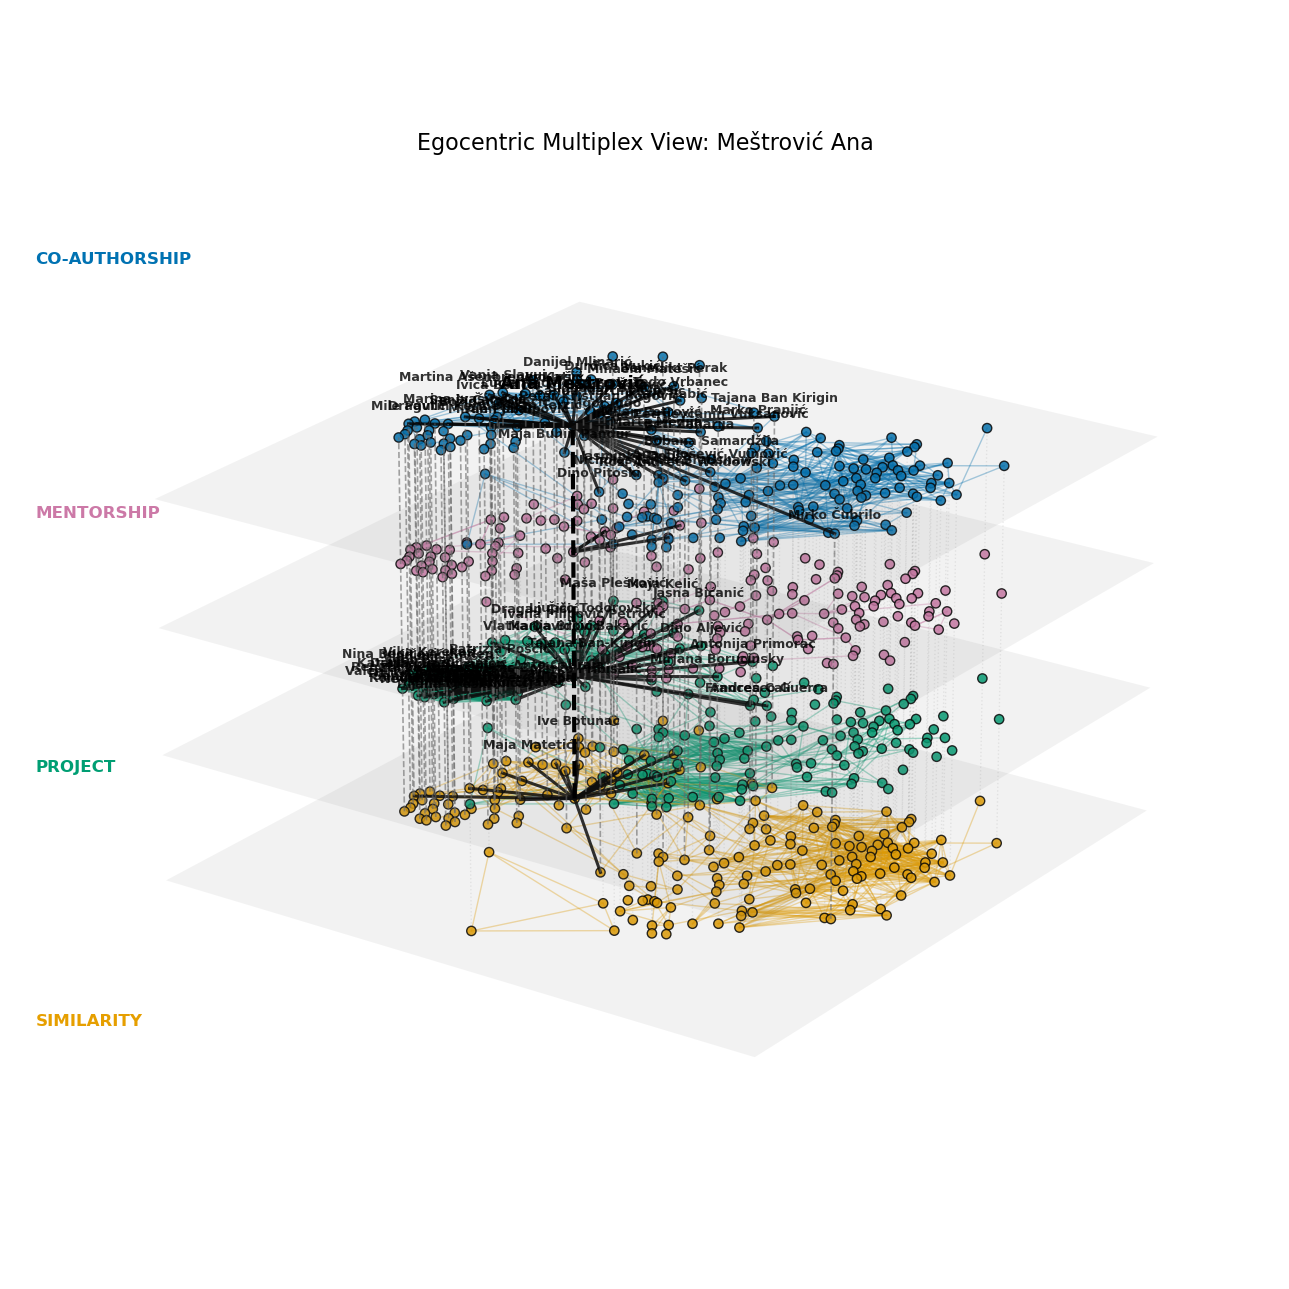

In [17]:
print("==========================================")
print("  PHASE D: 3D MULTIPLEX VISUALIZATION")
print("==========================================\n")

# ==========================================
# 1. NODE SELECTION & HIGHLIGHT LOGIC
# ==========================================
search_name = "meštrović_ana"
node_to_highlight = search_name

top_nodes_initial = df_centrality.head(120)['node_id'].tolist()

# Define priority scan from top plane down to bottom plane
priority_layers = ["co-authorship", "mentorship", "project", "similarity"]

neighbors_of_target = set()
neighbor_first_level = {} # Maps neighbor_node -> z_coordinate where they first connect

for layer_name in priority_layers:
    G = multiplex_graph[layer_name]
    z_val = {"co-authorship": 4, "mentorship": 3, "project": 2, "similarity": 1}[layer_name]
    
    if G.has_node(search_name):
        current_layer_neighbors = set()
        if G.is_directed():
            current_layer_neighbors.update(G.successors(search_name))
            current_layer_neighbors.update(G.predecessors(search_name))
        else:
            current_layer_neighbors.update(G.neighbors(search_name))
            
        for n in current_layer_neighbors:
            neighbors_of_target.add(n)
            # Record the highest priority Z-level where they first appeared!
            if n not in neighbor_first_level:
                neighbor_first_level[n] = z_val

nodes_to_include = set(top_nodes_initial)
nodes_to_include.add(search_name)
nodes_to_include.update(neighbors_of_target)
top_nodes = list(nodes_to_include)

# ==========================================
# 2. BUILD THE AGGREGATED GRAPH (For 2D Layout)
# ==========================================
G_agg = nx.Graph()
for layer_name, G in multiplex_graph.items():
    for u, v in G.edges():
        if u in top_nodes and v in top_nodes:
            G_agg.add_edge(u, v)

pos_2d = nx.spring_layout(G_agg, seed=42, k=0.5)

# ==========================================
# 3. SETUP 3D PLOT
# ==========================================
fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(111, projection='3d')

layers_meta = {
    "co-authorship": {"z": 4, "color": "#0072B2"}, # Blue
    "mentorship":    {"z": 3, "color": "#CC79A7"}, # Red
    "project":       {"z": 2, "color": "#009E73"}, # Green
    "similarity":    {"z": 1, "color": "#E69F00"}  # Orange
}

# ==========================================
# 4. DRAW LAYERS (PLANES)
# ==========================================
x_vals = [coords[0] for coords in pos_2d.values()]
y_vals = [coords[1] for coords in pos_2d.values()]
margin = 0.25
xx, yy = np.meshgrid(np.linspace(min(x_vals)-margin, max(x_vals)+margin, 2),
                     np.linspace(min(y_vals)-margin, max(y_vals)+margin, 2))

for layer, meta in layers_meta.items():
    z = meta["z"]
    ax.plot_surface(xx, yy, np.full_like(xx, z), alpha=0.08, color='grey', edgecolor='none')
    ax.text2D(0.02, z/5.0, layer.upper(), transform=ax.transAxes, color=meta["color"], fontsize=12, fontweight='bold')

# ==========================================
# 5. DRAW NODES AND INTRA-LAYER EDGES
# ==========================================
for layer_name, meta in layers_meta.items():
    G = multiplex_graph[layer_name]
    z = meta["z"]
    color = meta["color"]
    
    for u, v in G.edges():
        if u in pos_2d and v in pos_2d:
            x_edge = [pos_2d[u][0], pos_2d[v][0]]
            y_edge = [pos_2d[u][1], pos_2d[v][1]]
            z_edge = [z, z]
            
            if u == search_name or v == search_name:
                # Highlighted connections: Dark, bold
                ax.plot(x_edge, y_edge, z_edge, color='black', alpha=0.85, linewidth=2.2, zorder=6)
            else:
                ax.plot(x_edge, y_edge, z_edge, color=color, alpha=0.35, linewidth=1.0)
            
    xs = [pos_2d[n][0] for n in pos_2d]
    ys = [pos_2d[n][1] for n in pos_2d]
    zs = [z for _ in pos_2d]
    ax.scatter(xs, ys, zs, s=45, c=color, edgecolors='black', alpha=0.85, depthshade=True)

# ==========================================
# 6. DISTRIBUTED INTER-LAYER LABELS
# ==========================================
for node in pos_2d.keys():
    x, y = pos_2d[node]
    z_min, z_max = 1, 4  
    
    attrs = multiplex_graph['co-authorship'].nodes.get(node, {})
    display_name = f"{attrs.get('name', '')} {attrs.get('surname', '')}".strip()
    if not display_name: display_name = node
    
    if node == node_to_highlight:
        # Main Target: Floats proudly above the topmost plane (Z=4.3)
        ax.plot([x, x], [y, y], [z_min, z_max], color='black', linestyle='--', linewidth=3, zorder=10)
        ax.text(x, y, z_max + 0.3, display_name, color='black', fontsize=13, fontweight='bold', ha='center', zorder=12)
        
    elif node in neighbors_of_target:
        # Interacting Neighbor: Floats at the exact Z-level where they connect to Andrija!
        z_connected = neighbor_first_level.get(node, 1)
        
        ax.plot([x, x], [y, y], [z_min, z_max], color='dimgrey', linestyle='--', linewidth=1.2, alpha=0.6, zorder=9)
        ax.text(x, y, z_connected + 0.12, display_name, color='black', fontsize=9, fontweight='semibold', ha='center', alpha=0.8, zorder=11)
        
    else:
        # Background crowd: Faint dashed lines, completely silent
        ax.plot([x, x], [y, y], [z_min, z_max], color='grey', linestyle=':', alpha=0.15, linewidth=1)

# ==========================================
# 7. FINAL VIEW ADJUSTMENTS
# ==========================================
ax.set_zlim(0.5, 5.0) 
ax.set_axis_off() 
ax.view_init(elev=22, azim=-55) 

plt.title(f"Egocentric Multiplex View: {search_name.replace('_', ' ').title()}", fontsize=16, y=0.96)
plt.tight_layout()
plt.show()

## Multiinstitutional Version

In [33]:
import requests
import pandas as pd
import re
from tqdm import tqdm

# ==========================================
# 1. SETUP: NODE REGISTRY & DATA TABLES
# ==========================================
nodes_registry = {}
edges_table = []
keywords_table = []

# Define the institutions you want to analyze
institutions = [
    {"name": "FIDIT", "crosbi_id": 289, "mbu": 318},
    {"name": "FABRI", "crosbi_id": 303, "mbu": 335},
    {"name": "FZF", "crosbi_id": 288, "mbu": 316},
    {"name": "FM", "crosbi_id": 290, "mbu": 319},
    # Example for adding another institution (just replace the IDs):
    # {"name": "MATH", "crosbi_id": 130, "mbu": 130},
    # {"name": "RITEH", "crosbi_id": 69, "mbu": 69}
]

def get_or_create_node(ime, prezime, croris_id=None, pers_id=None):
    """
    Solves Entity Resolution: Matches 'Mile Pavlić' from Projects (persId) 
    with 'Mile Pavlić' from Publications (crorisId) using a synthetic key.
    """
    ime = str(ime).strip()
    prezime = str(prezime).strip()
    # Create a synthetic ID (e.g., "pavlić_mile")
    synth_id = f"{prezime.lower()}_{ime.lower()}"
    
    if synth_id not in nodes_registry:
        nodes_registry[synth_id] = {
            "node_id": synth_id,
            "name": ime,
            "surname": prezime,
            "croris_id": croris_id,
            "pers_id": pers_id
        }
    else:
        # Update IDs if we discover them later in different APIs
        if croris_id: nodes_registry[synth_id]["croris_id"] = croris_id
        if pers_id: nodes_registry[synth_id]["pers_id"] = pers_id
        
    return synth_id

# Sets to keep track of processed data to prevent duplication in inter-institutional collaborations
processed_pubs = set()
processed_projects = set()

# ==========================================
# 2. EXTRACT LAYERS 1, 2, & 3 (CROSBI API)
# ==========================================
print("Fetching Publications from CROSBI...")

for inst in institutions:
    institution_url = f"https://www.croris.hr/crosbi-api/ustanova/{inst['crosbi_id']}"
    response = requests.get(institution_url)

    if response.status_code == 200:
        publications = response.json().get('_links', {}).get('publikacije', [])
    else:
        publications = []
        print(f"Error fetching publications list for {inst['name']}.")

    # For testing purposes, you might want to slice this `publications[:50]`
    for pub in tqdm(publications, desc=f"Pubs {inst['name']}"):
        pub_url = pub['href']
        
        # Deduplication check
        if pub_url in processed_pubs:
            continue
        processed_pubs.add(pub_url)
        
        pub_resp = requests.get(pub_url)
        
        if pub_resp.status_code == 200:
            pub_data = pub_resp.json()
            pub_id = pub_data.get('crosbiId', 'unknown')
            
            # Safely extract year
            try:
                year = int(pub_data.get('godina', 0))
            except ValueError:
                year = 0
                
            authors = []
            supervisors = []
            
            # 2a. Parse People (Authors & Mentors)
            if 'osobeResources' in pub_data and '_embedded' in pub_data['osobeResources']:
                for osoba in pub_data['osobeResources']['_embedded'].get('osobe', []):
                    role_id = osoba.get('funkcija', {}).get('id')
                    croris_id = osoba.get('crorisId')
                    
                    # Register the node
                    node_id = get_or_create_node(osoba.get('ime', ''), osoba.get('prezime', ''), croris_id=croris_id)
                    
                    if role_id == 905: # Author
                        authors.append(node_id)
                    elif role_id == 907: # Supervisor/Mentor
                        supervisors.append(node_id)
                        authors.append(node_id) # Mentors are usually authors too
            
            # 2b. Build Layer 1: Co-authorship Edges
            # Create an edge between every pair of authors
            for i in range(len(authors)):
                for j in range(i + 1, len(authors)):
                    edges_table.append({
                        "source": authors[i],
                        "target": authors[j],
                        "layer": "co-authorship",
                        "weight": 1,
                        "year_start": year,
                        "year_end": year,
                        "context": f"pub_{pub_id}"
                    })
                    
            # 2c. Build Layer 2: Mentorship Edges (Directed)
            for sup in supervisors:
                for auth in authors:
                    if sup != auth:
                        edges_table.append({
                            "source": sup, # Source is mentor
                            "target": auth, # Target is student/author
                            "layer": "mentorship",
                            "weight": 1,
                            "year_start": year,
                            "year_end": year,
                            "context": f"pub_{pub_id}"
                        })
                        
            # 2d. Build Layer 3: Keyword Associations
            if 'kljucneRijeci' in pub_data:
                for kr in pub_data['kljucneRijeci']:
                    naziv = kr.get('naziv', '')
                    # Split by comma or semicolon and clean up
                    kw_list = [k.strip().lower() for k in re.split(r'[;,]', naziv) if k.strip()]
                    
                    for kw in kw_list:
                        for auth in authors:
                            keywords_table.append({
                                "node_id": auth,
                                "keyword": kw,
                                "year": year,
                                "context": f"pub_{pub_id}"
                            })

# ==========================================
# 3. EXTRACT LAYER 4 (PROJEKTI API)
# ==========================================
print("\nFetching Projects from CRORIS...")

for inst in institutions:
    projects_url = f"https://www.croris.hr/projekti-api/projekt/ustanova/{inst['mbu']}"
    proj_resp = requests.get(projects_url)

    if proj_resp.status_code == 200:
        projects_data = proj_resp.json().get('_embedded', {}).get('projekti', [])
    else:
        projects_data = []
        print(f"Error fetching projects for {inst['name']}.")

    for proj in tqdm(projects_data, desc=f"Proj {inst['name']}"):
        proj_id = proj.get('id', 'unknown')
        
        # Deduplication check
        if proj_id in processed_projects:
            continue
        processed_projects.add(proj_id)
        
        # Safely extract start and end years
        try:
            start_year = int(proj.get('pocetak', '').split('.')[-1])
        except (ValueError, AttributeError):
            start_year = 0
            
        try:
            end_year = int(proj.get('kraj', '').split('.')[-1])
        except (ValueError, AttributeError):
            end_year = 2026 # Assume ongoing if no end date
            
        team_members = []
        
        # Extract People on the project
        if 'osobeResources' in proj and '_embedded' in proj['osobeResources']:
            for osoba in proj['osobeResources']['_embedded'].get('osobe', []):
                pers_id = osoba.get('persId')
                # Register node
                node_id = get_or_create_node(osoba.get('ime', ''), osoba.get('prezime', ''), pers_id=pers_id)
                team_members.append(node_id)
                
        # Build Layer 4: Project Co-participation
        for i in range(len(team_members)):
            for j in range(i + 1, len(team_members)):
                edges_table.append({
                    "source": team_members[i],
                    "target": team_members[j],
                    "layer": "project",
                    "weight": 1,
                    "year_start": start_year,
                    "year_end": end_year,
                    "context": f"proj_{proj_id}"
                })

# ==========================================
# 4. EXPORT TO PANDAS DATAFRAMES
# ==========================================
df_nodes = pd.DataFrame(list(nodes_registry.values()))
df_edges = pd.DataFrame(edges_table)
df_keywords = pd.DataFrame(keywords_table)

print("\n--- EXTRACTION COMPLETE ---")
print(f"Total Unique Nodes (Researchers): {len(df_nodes)}")
print(f"Total Edge Records: {len(df_edges)}")
print(f"Total Keyword Associations: {len(df_keywords)}")

inst_suffix = "_".join([inst['name'] for inst in institutions])

print("\n--- EXTRACTION COMPLETE ---")
print(f"Institutions processed: {', '.join([inst['name'] for inst in institutions])}")
print(f"Total Unique Nodes (Researchers): {len(df_nodes)}")
print(f"Total Edge Records: {len(df_edges)}")
print(f"Total Keyword Associations: {len(df_keywords)}")

# Define filenames
nodes_file = f"nodes_{inst_suffix}.csv"
edges_file = f"edges_{inst_suffix}.csv"
keywords_file = f"keywords_{inst_suffix}.csv"

# Save to CSV
df_nodes.to_csv(nodes_file, index=False)
df_edges.to_csv(edges_file, index=False)
df_keywords.to_csv(keywords_file, index=False)

print(f"\nFiles saved successfully:")
print(f" - {nodes_file}")
print(f" - {edges_file}")
print(f" - {keywords_file}")

Fetching Publications from CROSBI...


Pubs FM: 100%|██████████| 864/864 [00:48<00:00, 17.69it/s]



Fetching Projects from CRORIS...


Proj FM: 100%|██████████| 57/57 [00:00<00:00, 62065.25it/s]



--- EXTRACTION COMPLETE ---
Total Unique Nodes (Researchers): 1882
Total Edge Records: 44840
Total Keyword Associations: 70883

--- EXTRACTION COMPLETE ---
Institutions processed: FIDIT, FABRI, FZF, FM
Total Unique Nodes (Researchers): 1882
Total Edge Records: 44840
Total Keyword Associations: 70883

Files saved successfully:
 - nodes_FIDIT_FABRI_FZF_FM.csv
 - edges_FIDIT_FABRI_FZF_FM.csv
 - keywords_FIDIT_FABRI_FZF_FM.csv
